In [4]:
import gzip
from collections import defaultdict
import os

def readGz(path):
  for l in gzip.open(path, 'rt'):
    yield eval(l)

def readCSV(path):
  f = gzip.open(path, 'rt')
  f.readline()
  for l in f:
    yield l.strip().split(',')

### baseline rating (1.63),read(0.7), category(0.35)


In [8]:
allRatings = []
userRatings = defaultdict(list)
train_inter = [d.split(',') for d in os.popen("cat train_Interactions.csv").read().split('\n')[1:-1]]
for user,book,r in readCSV("train_Interactions.csv.gz"):
  r = int(r)
  allRatings.append(r)
  userRatings[user].append(r)

globalAverage = sum(allRatings) / len(allRatings)
userAverage = {}
for u in userRatings:
  userAverage[u] = sum(userRatings[u]) / len(userRatings[u])

predictions = open("predictions_Rating.csv", 'w')
for l in open("pairs_Rating.csv"):
  if l.startswith("userID"):
    #header
    predictions.write(l)
    continue
  u,b = l.strip().split(',')
  if u in userAverage:
    predictions.write(u + ',' + b + ',' + str(userAverage[u]) + '\n')
  else:
    predictions.write(u + ',' + b + ',' + str(globalAverage) + '\n')

predictions.close()

### my rating

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. Load Data
df = pd.read_csv("train_Interactions.csv")

# ---------------------------------------------------------
# 1. PREDICTION FUNCTION (With Exclusive Sets)
# ---------------------------------------------------------
def predictRating(user, item, ratingMean, userAverages, itemAverages, 
                  reviewsPerUser, usersPerItem, k_user=5, k_item=10):
    
    # --- 2. FALLBACK TO VISUAL TUNED LOGIC ---
    USER_ANCHOR = 4.0       
    HATER_THRESHOLD = 2.0   
    SUPER_BOOK_THRESHOLD = 4.3 

    mu = ratingMean
    
    u_avg = userAverages.get(user, USER_ANCHOR) 
    num_user_reviews = len(reviewsPerUser.get(user, []))
    
    i_avg = itemAverages.get(item, mu)
    num_item_raters = len(usersPerItem.get(item, set()))
    
    b_i = (i_avg - mu) * (num_item_raters / (num_item_raters + k_item))
    
    if i_avg >= SUPER_BOOK_THRESHOLD:
        return 5.0

    b_u_raw = u_avg - USER_ANCHOR 
    b_u = b_u_raw * (num_user_reviews / (num_user_reviews + k_user))
    
    if u_avg < HATER_THRESHOLD:
        prediction = u_avg 
    else:
        prediction = USER_ANCHOR + b_u + b_i

    if prediction > 5: prediction = 5
    if prediction < 0: prediction = 0
        
    return prediction

# ---------------------------------------------------------
# 2. K-FOLD CROSS VALIDATION
# ---------------------------------------------------------
N_SPLITS = 5
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
all_results = []

print(f"Starting {N_SPLITS}-Fold CV with Exclusive Sets...")

for fold, (train_idx, val_idx) in enumerate(kfold.split(df)):
    print(f"\n--- Processing Fold {fold+1}/{N_SPLITS} ---")
    
    train_data = df.iloc[train_idx].copy()
    val_data = df.iloc[val_idx].copy()

    # --- A. Standard Stats ---
    ratingMean = train_data['rating'].mean()
    userAverages = train_data.groupby('userID')['rating'].mean().to_dict()
    itemAverages = train_data.groupby('bookID')['rating'].mean().to_dict()
    reviewsPerUser = train_data.groupby('userID')['bookID'].apply(list).to_dict()
    usersPerItem = train_data.groupby('bookID')['userID'].apply(set).to_dict()

    # --- B. BUILD EXCLUSIVE SETS ---
    print("   Building Exclusive Book Sets...")
    
    # 1. Calc Z-Scores
    book_stats = train_data.groupby('bookID')['rating'].agg(['mean', 'std'])
    book_stats['std'] = book_stats['std'].fillna(1.0).replace(0, 1.0)
    book_zscores = ((book_stats['mean'] - ratingMean) / book_stats['std']).to_dict()
    train_data['book_zscore'] = train_data['bookID'].map(book_zscores)
    
    # 2. Find Candidates for each rating
    candidates = {r: set() for r in range(6)}
    for r in range(6):
        subset = train_data[train_data['rating'] == r]
        if subset.empty: continue
        q1 = subset['book_zscore'].quantile(0.25)
        q3 = subset['book_zscore'].quantile(0.75)
        
        # Identify books in this range
        valid_books = [bid for bid, z in book_zscores.items() if q1 <= z <= q3]
        candidates[r] = set(valid_books)

    # 3. Enforce Exclusivity (Remove Overlaps)
    exclusive_books = {r: set() for r in range(6)}
    for r in range(6):
        # Start with candidates
        current_set = candidates[r].copy()
        
        # Subtract ALL other sets
        for other_r in range(6):
            if r == other_r: continue
            current_set = current_set - candidates[other_r]
            
        exclusive_books[r] = current_set
        
    print(f"      Unique Books -> Rating 0: {len(exclusive_books[0])}, Rating 1: {len(exclusive_books[1])}, Rating 5: {len(exclusive_books[5])}")

    # --- C. Prediction Loop ---
    print("   Making predictions...")
    for row in tqdm(val_data.itertuples(), total=len(val_data)):
        pred = predictRating(row.userID, row.bookID, ratingMean,userAverages, itemAverages,
            reviewsPerUser, usersPerItem,exclusive_books, k_user=5, k_item=10)
        
        all_results.append({
            'actual': row.rating,
            'predicted': pred,
            'fold': fold + 1
        })

# ---------------------------------------------------------
# 3. RESULTS
# ---------------------------------------------------------
results_df = pd.DataFrame(all_results)
results_df['predicted_clipped'] = results_df['predicted'].clip(0, 5)
results_df['sq_error'] = (results_df['actual'] - results_df['predicted_clipped'])**2
results_df['abs_error'] = (results_df['actual'] - results_df['predicted_clipped']).abs()

overall_rmse = np.sqrt(results_df['sq_error'].mean())
print(f"\nOverall RMSE: {overall_rmse:.4f}")

print("\n--- Error by Actual Rating ---")
print(results_df.groupby('actual')[['sq_error', 'abs_error']].mean())

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from scipy.stats import zscore, mode

# Load data
train_inter = pd.read_csv("train_Interactions.csv")

# --- Book-level features ---
# Count interactions per book
book_interactions = train_inter.groupby("bookID")["rating"].count()
train_inter["book_interactions"] = train_inter["bookID"].map(book_interactions)

# Z-score of ratings per book
book_mean = train_inter.groupby("bookID")["rating"].transform("mean")
book_std = train_inter.groupby("bookID")["rating"].transform("std").replace(0, np.nan)
train_inter["bookID_zscore"] = (train_inter["rating"] - book_mean) / book_std

# --- User-level features ---
# Count interactions per user
user_interactions = train_inter.groupby("userID")["rating"].count()
train_inter["user_interactions"] = train_inter["userID"].map(user_interactions)

# Z-score of ratings per user
user_mean = train_inter.groupby("userID")["rating"].transform("mean")
user_std = train_inter.groupby("userID")["rating"].transform("std").replace(0, np.nan)
train_inter["userID_zscore"] = (train_inter["rating"] - user_mean) / user_std

# User summary stats
user_mean_map = train_inter.groupby("userID")["rating"].mean()
user_median_map = train_inter.groupby("userID")["rating"].median()
user_mode_map = train_inter.groupby("userID")["rating"].agg(lambda x: mode(x, keepdims=True)[0][0])

train_inter["user_mean"] = train_inter["userID"].map(user_mean_map)
train_inter["user_median"] = train_inter["userID"].map(user_median_map)
train_inter["user_mode"] = train_inter["userID"].map(user_mode_map)

# --- Final check ---
for i in range(0,6):
    print(50*'=')
    print(f"stats for rating {i}")
    print(train_inter[train_inter['rating']==i][['bookID_zscore','userID_zscore',"book_interactions"]].describe())
    print(50*'=')

stats for rating 0
       bookID_zscore  userID_zscore  book_interactions
count   10772.000000    9997.000000       10778.000000
mean       -2.487837      -1.446295         120.744387
std         0.694038       0.705793         152.255316
min        -5.505091      -5.918364           1.000000
25%        -2.937072      -1.936492          20.000000
50%        -2.516598      -1.391450          58.000000
75%        -2.011246      -0.877058         169.000000
max        -0.500000      -0.208514         974.000000
stats for rating 1
       bookID_zscore  userID_zscore  book_interactions
count    4395.000000    4371.000000        4396.000000
mean       -1.849080      -1.469061         175.112147
std         0.518858       0.570631         222.000145
min        -4.305279      -4.477215           1.000000
25%        -2.162776      -1.837552          23.000000
50%        -1.859838      -1.457738          76.000000
75%        -1.557459      -1.086534         232.000000
max         0.707107       

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import numpy as np

# Load the data
df = pd.read_csv('train_Interactions.csv')

# Create binary label: 1 if rating > 0 (read), 0 otherwise (not read)
df['read'] = (df['rating'] > 0).astype(int)

# Compute user-level features
user_stats = df.groupby('userID').agg(
    user_read_rate=('read', 'mean'),
    user_num_books=('bookID', 'count')
).reset_index()

# Compute book-level features
book_stats = df.groupby('bookID').agg(
    book_read_rate=('read', 'mean'),
    book_num_users=('userID', 'count')
).reset_index()

# Merge features back into the dataframe
df = df.merge(user_stats, on='userID')
df = df.merge(book_stats, on='bookID')

# Split into train and test sets
train, test = train_test_split(df, test_size=0.2, random_state=42)

# Define features
features = ['user_read_rate', 'user_num_books', 'book_read_rate', 'book_num_users']

# Prepare training data
X_train = train[features]
y_train = train['read']
X_train = sm.add_constant(X_train)  # Add intercept term

# Train logistic regression model
model = sm.Logit(y_train, X_train)
result = model.fit()

# Print model summary for interpretation
print(result.summary())

# Evaluate on test set
X_test = test[features]
y_test = test['read']
X_test = sm.add_constant(X_test)
preds = result.predict(X_test)
acc = ((preds > 0.5).astype(int) == y_test).mean()
print('Test Accuracy:', acc)

# Baseline: Always predict 1 (read)
baseline_acc = (y_test == 1).mean()
print('Baseline Accuracy (always predict 1):', baseline_acc)

# Function to predict for a given userID and bookID
def predict_read(user_id, book_id, result, df, user_stats, book_stats):
    """
    Predicts whether the user has read the book (1) or not (0).
    
    Parameters:
    - user_id: str, the userID
    - book_id: str, the bookID
    - result: fitted statsmodels Logit result object
    - df: pandas DataFrame, the original dataset
    - user_stats: pandas DataFrame, precomputed user statistics
    - book_stats: pandas DataFrame, precomputed book statistics
    
    Returns:
    - int: 1 (read) or 0 (not read)
    """
    # Retrieve user features; default to global means if unseen
    user_data = user_stats[user_stats['userID'] == user_id]
    if user_data.empty:
        user_read_rate = df['read'].mean()
        user_num_books = 0
    else:
        user_read_rate = user_data['user_read_rate'].values[0]
        user_num_books = user_data['user_num_books'].values[0]
    
    # Retrieve book features; default to global means if unseen
    book_data = book_stats[book_stats['bookID'] == book_id]
    if book_data.empty:
        book_read_rate = df['read'].mean()
        book_num_users = 0
    else:
        book_read_rate = book_data['book_read_rate'].values[0]
        book_num_users = book_data['book_num_users'].values[0]
    
    # Prepare input array (with constant/intercept)
    x = np.array([[1.0, user_read_rate, user_num_books, book_read_rate, book_num_users]])
    
    # Predict probability and threshold
    prob = result.predict(x)[0]
    return int(prob > 0.5)

# Example usage (replace with actual IDs)
# prediction = predict_read('u67805239', 'b61372131', result, df, user_stats, book_stats)
# print('Prediction:', prediction)

In [13]:
import gzip
import pandas as pd
def readCSV(path):
  f = gzip.open(path, 'rt')
  f.readline()
  for l in f:
    yield l.strip().split(',')

def readGz(path):
  for l in gzip.open(path, 'rt'):
    yield eval(l)

cat_data = pd.DataFrame([l for l in readGz("/home/scotty/dsc_256/fall_25/assignment1/test_Category.json.gz")])
print(cat_data.describe())
cat_data.to_csv('test_cat_data.csv',index=False)


             rating       n_votes
count  10000.000000  10000.000000
mean       3.805200      1.279600
std        1.159995      7.776829
min        0.000000     -1.000000
25%        3.000000      0.000000
50%        4.000000      0.000000
75%        5.000000      1.000000
max        5.000000    440.000000


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import trim_mean,kurtosis,zscore,skew,iqr

df = pd.read_csv('train_cat_data.csv')

df['review_len'] = len(df['review_text'])
df['norm_review_len'] = df['review_len']/df['review_len'].max()
df['genre_mean'] = df.groupby('genre')['rating'].mean()
df['user_zscore'] = df.groupby('user_id')['rating'].transform(zscore)
df['review_zscore'] = df.groupby('review_id')['rating'].transform(zscore)
df.loc[df['review_text'].str.contains("graphic novel|comic book"),'comic_str'] = 1
df.loc[df['review_text'].str.contains("high school"),'ya_str'] = 1
df.loc[df['review_text'].str.contains("picture book|childrens book|young children"),'kids_str'] = 1
review_counts = df['review_id'].value_counts()
user_counts = df['user_id'].value_counts()
df['user_count'] = df['user_id'].map(user_counts)
df['review_count'] = df['review_id'].map(review_counts)
num_cols = ['norm_review_len','genre_mean','user_zscore','review_zscore','comic_str','ya_str','kids_str','user_count','review_count']

/home/scotty/venvs/ucsd/lib/python3.12/site-packages/pandas/core/groupby/generic.py:557: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = func(group, *args, **kwargs)
/home/scotty/venvs/ucsd/lib/python3.12/site-packages/pandas/core/groupby/generic.py:557: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = func(group, *args, **kwargs)
/home/scotty/venvs/ucsd/lib/python3.12/site-packages/pandas/core/groupby/generic.py:557: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = func(group, *args, **kwargs)
/home/scotty/venvs/ucsd/lib/python3.12/site-packages/pandas/core/groupby/generic.py:557: RuntimeWarning: Prec

mystery_thriller_crime
comics_graphic
young_adult
fantasy_paranormal
children
genre
fantasy_paranormal        751
young_adult               540
mystery_thriller_crime    449
comics_graphic            105
children                   86
Name: count, dtype: int64


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import zscore

# 1. Load Data
df = pd.read_csv('train_cat_data.csv')

# 2. Feature Engineering (Corrected)
# FIX: Use .str.len() to get length of text, not length of dataframe
df['review_len'] = df['review_text'].str.len()
df['norm_review_len'] = df['review_len'] / df['review_len'].max()

# FIX: Initialize columns with 0 first to avoid NaNs
df['comic_str'] = 0
df['ya_str'] = 0
df['kids_str'] = 0

# Apply text flags (case=False makes it insensitive to capitalization)
df.loc[df['review_text'].str.contains("graphic novel|comic book", case=False, na=False), 'comic_str'] = 1
df.loc[df['review_text'].str.contains("high school", case=False, na=False), 'ya_str'] = 1
df.loc[df['review_text'].str.contains("picture book|childrens book|young children", case=False, na=False), 'kids_str'] = 1

# Counts and Z-Scores
user_counts = df['user_id'].value_counts()
df['user_count'] = df['user_id'].map(user_counts)

# FIX: Handle single-review users (std=0) by filling NaNs with 0
df['user_zscore'] = df.groupby('user_id')['rating'].transform(lambda x: zscore(x, ddof=1) if len(x) > 1 else 0).fillna(0)
df['fantasy_str'] = 0
df['mystery_str'] = 0

df.loc[df['review_text'].str.contains("magic|dragon|wizard|world|series", case=False), 'fantasy_str'] = 1
df.loc[df['review_text'].str.contains("mystery|crime|murder|detective|thriller", case=False), 'mystery_str'] = 1

# Don't forget to add them to your feature list!
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Create TF-IDF Features (limit to top 500 words to keep it fast)
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
text_features = tfidf.fit_transform(df['review_text'])

# 2. Your other numerical features
# (Ensure X_numerical is a DataFrame or 2D array)
numerical_features = df[['norm_review_len', 'user_zscore']].values

# 3. Combine them
X = hstack([numerical_features, text_features])
y = df['genre']


# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf.fit(X_train, y_train)

# 6. Evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# --- Plotting ---

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_773655/841638107.py:33: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df['user_zscore'] = df.groupby('user_id')['rating'].transform(lambda x: zscore(x, ddof=1) if len(x) > 1 else 0).fillna(0)
/tmp/ipykernel_773655/841638107.py:33: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df['user_zscore'] = df.groupby('user_id')['rating'].transform(lambda x: zscore(x, ddof=1) if len(x) > 1 else 0).fillna(0)
/tmp/ipykernel_773655/841638107.py:33: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df['user_zscore'] = df.groupby('user_id')['rating'].transform(lambda x: zscore(x, ddof=1) if len(x) > 1 else 0).fillna(0

KeyboardInterrupt: 

In [56]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires labels to be integers (0, 1, 2...), not strings ('Fantasy')
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Train
model = XGBClassifier(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train_enc)

# Predict
preds = model.predict(X_test)
# Convert numbers back to names if needed: le.inverse_transform(preds)

In [58]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Get the accuracy (percentage)
acc = accuracy_score(y_test_enc, preds)
print(f"Accuracy: {acc:.4f}")  # e.g., 0.6500 means 65% correct

# 2. Get precision/recall per class (Most useful!)
# This tells you if you are failing specifically on 'Comics' or 'Mystery'
print(classification_report(y_test_enc, preds, target_names=le.classes_))

Accuracy: 0.6036
                        precision    recall  f1-score   support

              children       0.71      0.45      0.55      1815
        comics_graphic       0.76      0.41      0.53      1474
    fantasy_paranormal       0.53      0.82      0.65      7343
mystery_thriller_crime       0.73      0.54      0.62      5403
           young_adult       0.63      0.43      0.51      3965

              accuracy                           0.60     20000
             macro avg       0.67      0.53      0.57     20000
          weighted avg       0.64      0.60      0.59     20000



In [61]:
from sklearn.svm import LinearSVC
model = LinearSVC(class_weight='balanced', verbose=1, max_iter=2000)
model.fit(X_train, y_train)

print(f"Accuracy: {model.score(X_test, y_test)}")

[LibLinear]iter  1 act 3.702e+04 pre 3.702e+04 delta 6.266e-01 f 8.887e+04 |g| 1.181e+05 CG   1
cg reaches trust region boundary
iter  2 act 3.771e+03 pre 3.770e+03 delta 1.346e+00 f 5.185e+04 |g| 7.844e+03 CG   1
cg reaches trust region boundary
iter  3 act 8.003e+03 pre 8.015e+03 delta 2.593e+00 f 4.808e+04 |g| 1.344e+04 CG   3
cg reaches trust region boundary
iter  4 act 8.447e+03 pre 8.134e+03 delta 3.666e+00 f 4.008e+04 |g| 8.500e+03 CG   3
iter  5 act 3.564e+03 pre 3.034e+03 delta 4.409e+00 f 3.163e+04 |g| 4.650e+03 CG   5
iter  6 act 8.349e+02 pre 7.065e+02 delta 4.409e+00 f 2.807e+04 |g| 3.413e+03 CG   5
iter  7 act 2.433e+02 pre 2.176e+02 delta 4.409e+00 f 2.723e+04 |g| 1.527e+03 CG   6
iter  8 act 4.599e+01 pre 4.303e+01 delta 4.409e+00 f 2.699e+04 |g| 4.803e+02 CG   7
iter  9 act 1.096e+01 pre 1.012e+01 delta 4.409e+00 f 2.694e+04 |g| 1.014e+02 CG  13
iter 10 act 1.752e+00 pre 1.559e+00 delta 4.409e+00 f 2.693e+04 |g| 2.625e+01 CG  19
iter 11 act 1.713e-01 pre 1.669e-01 delt

In [62]:
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Increase Vocabulary (CRITICAL STEP)
# 1000 words is not enough to distinguish subtle genres. 
# Increasing to 20,000 allows the model to find niche words for "Comics" and "Children".
tfidf = TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1, 2))
text_features = tfidf.fit_transform(df['review_text'])

# 2. Combine Features
# We don't need 'user_count' or others as much, but we can keep zscore
X = hstack([text_features, df[['norm_review_len', 'user_zscore']].values])
y = df['genre']

# 3. Train Linear SVM
# LinearSVC is the industry standard for text classification.
# class_weight='balanced' is MANDATORY here to fix the low recall on Comics/Children.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearSVC(class_weight='balanced', verbose=1, max_iter=2000)
model.fit(X_train, y_train)

print(f"Accuracy: {model.score(X_test, y_test)}")

[LibLinear]iter  1 act 3.663e+04 pre 3.663e+04 delta 6.370e-01 f 8.887e+04 |g| 1.150e+05 CG   1
cg reaches trust region boundary
iter  2 act 1.801e+03 pre 1.797e+03 delta 7.804e-01 f 5.224e+04 |g| 4.786e+03 CG   2
cg reaches trust region boundary
iter  3 act 3.872e+03 pre 3.934e+03 delta 1.382e+00 f 5.044e+04 |g| 1.278e+04 CG   3
cg reaches trust region boundary
iter  4 act 4.720e+03 pre 4.716e+03 delta 3.636e+00 f 4.657e+04 |g| 6.624e+03 CG   3
cg reaches trust region boundary
iter  5 act 9.931e+03 pre 9.848e+03 delta 7.872e+00 f 4.185e+04 |g| 8.387e+03 CG   3
cg reaches trust region boundary
iter  6 act 9.597e+03 pre 8.447e+03 delta 9.885e+00 f 3.191e+04 |g| 3.815e+03 CG   4
cg reaches trust region boundary
iter  7 act 4.396e+03 pre 3.591e+03 delta 1.303e+01 f 2.232e+04 |g| 3.391e+03 CG   4
cg reaches trust region boundary
iter  8 act 3.115e+03 pre 3.096e+03 delta 1.537e+01 f 1.792e+04 |g| 3.495e+03 CG   5
cg reaches trust region boundary
iter  9 act 2.596e+03 pre 2.269e+03 delta 1.8

In [66]:
# Load test data
test_df = pd.read_csv("test_cat_data.csv")

# Transform review_text using the SAME fitted tfidf
test_text_features = tfidf.transform(test_df['review_text'])
# --- Test preprocessing ---
# Transform text with the SAME fitted tfidf
test_text_features = tfidf.transform(test_df['review_text'])

# Recreate numeric features exactly as in training
test_df['norm_review_len'] = test_df['review_text'].str.split().str.len()
test_df['norm_review_len'] = (test_df['norm_review_len'] - df['norm_review_len'].mean()) / df['norm_review_len'].std()

# If you had user_zscore in training, recompute it here.
# For test users not seen in training, fill with 0.
test_df['user_zscore'] = test_df['user_id'].map(df.groupby('user_id')['user_zscore'].mean()).fillna(0)

# Stack features in the same order
test_extra_features = test_df[['norm_review_len', 'user_zscore']].values
X_test_final = hstack([test_text_features, test_extra_features])

# Predict
test_preds = model.predict(X_test_final)
test_df['predicted_genre'] = test_preds


# Inspect first few predictions
print(test_df[['review_text', 'predicted_genre']].head())

# Optionally save to CSV
test_df.to_csv("test_cat_predictions.csv", index=False)


                                         review_text predicted_genre
0  love it \n it's that kind of crime-mystery nov...     young_adult
1  This latest book from S.J. Bolton, features tw...     young_adult
2  Maybe I'm dumb, but after reading two of these...     young_adult
3  This is a re-read for me in anticipation of Th...     young_adult
4  Book: The Beast (Black Dagger Brotherhood #14)...     young_adult


In [46]:
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import collections
import string
from scipy.stats import trim_mean,kurtosis,zscore,skew,iqr

# 1. Download necessary NLTK data (run this once)
#nltk.download('punkt')
#nltk.download('punkt_tab')
#nltk.download('stopwords')

# 3. Define a function to get Bigrams
def get_clean_bigrams(text_list):
    # Combine all text for this category into one big string
    text = " ".join(text_list).lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords (optional but recommended)
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]
    
    # Generate Bigrams
    # ngrams(tokens, 2) creates a generator, list() converts it
    bigrams = list(ngrams(tokens, 2))
    
    return bigrams

# 4. Apply to each category
top_n = 20 # How many top bigrams you want
results = {}

for category in df['genre'].unique():
    # Filter data for the current category
    category_text = df[df['genre'] == category]['review_text']
    
    # Get all bigrams for this category
    bigrams = get_clean_bigrams(category_text)
    
    # Count frequencies
    counts = collections.Counter(bigrams)
    
    # Store the most common ones
    results[category] = counts.most_common(top_n)

# 5. View Results
for cat, common_bigrams in results.items():
    print(f"\nCategory: {cat}")
    for bg, count in common_bigrams:
        print(f"  {bg}: {count}")


Category: mystery_thriller_crime
  ('read', 'book'): 1221
  ('first', 'book'): 1171
  ('main', 'character'): 1114
  ('really', 'enjoyed'): 995
  ('ive', 'read'): 931
  ('twists', 'turns'): 930
  ('well', 'written'): 913
  ('book', 'series'): 837
  ('even', 'though'): 835
  ('honest', 'review'): 811
  ('next', 'book'): 748
  ('felt', 'like'): 692
  ('cant', 'wait'): 674
  ('looking', 'forward'): 669
  ('enjoyed', 'book'): 669
  ('dont', 'know'): 664
  ('main', 'characters'): 624
  ('book', 'read'): 621
  ('good', 'read'): 601
  ('reading', 'book'): 601

Category: comics_graphic
  ('graphic', 'novel'): 1037
  ('graphic', 'novels'): 340
  ('comic', 'book'): 295
  ('feel', 'like'): 214
  ('dont', 'know'): 210
  ('first', 'volume'): 185
  ('really', 'enjoyed'): 183
  ('felt', 'like'): 180
  ('ive', 'read'): 174
  ('even', 'though'): 174
  ('cant', 'wait'): 162
  ('im', 'sure'): 154
  ('next', 'volume'): 134
  ('really', 'liked'): 129
  ('de', 'la'): 129
  ('looking', 'forward'): 129
  ('ar

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# --- CONFIGURATION ---
TRAIN_FILE = 'train_cat_data.csv'
TEST_FILE = 'test_cat_data.csv' # Using the new CSV you uploaded
OUTPUT_FILE = 'predictions_Category.csv'

# --- 1. LOAD DATA ---
print("1. Loading Data...")
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

# Handle column naming differences (just in case)
text_col_train = 'review_text' if 'review_text' in train_df.columns else 'text'
text_col_test = 'review_text' if 'review_text' in test_df.columns else 'text'

# Handle Label Mapping
catDict = {
  "children": 0,
  "comics_graphic": 1,
  "fantasy_paranormal": 2,
  "mystery_thriller_crime": 3,
  "young_adult": 4
}

# If training labels are strings ("children"), map them to numbers
if train_df['genre'].dtype == 'O':
    train_df['label'] = train_df['genre'].map(catDict)
else:
    train_df['label'] = train_df['genre']

# Drop any rows that didn't map correctly
train_df = train_df.dropna(subset=['label'])

# --- 2. VECTORIZATION (The "Unique Words" Step) ---
print("2. Extracting Distinctive Words (TF-IDF)...")

# This finds unique words AUTOMATICALLY.
# ngram_range=(1, 2) means it looks for "comic" AND "comic book"
vectorizer = TfidfVectorizer(
    max_features=25000,      # Keep top 25,000 distinctive words/phrases
    ngram_range=(1, 2),      # Unigrams and Bigrams
    stop_words='english',    # Remove noise like "the", "and"
    sublinear_tf=True        # smooths counts (logarithmic)
)

# Learn vocabulary from Train, apply to Test
X_train = vectorizer.fit_transform(train_df[text_col_train].fillna(""))
X_test = vectorizer.transform(test_df[text_col_test].fillna(""))
y_train = train_df['label']

# --- 3. TRAINING ---
print("3. Training Model...")

# LinearSVC is the best model for this.
# class_weight='balanced' IS CRITICAL -> It stops the "Everything is Fantasy" bug
model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
model.fit(X_train, y_train)

# --- 4. PREDICTION ---
print("4. Predicting...")
predictions = model.predict(X_test)

# --- 5. SAVING ---
submission = pd.DataFrame({
    'userID': test_df['user_id'],
    'reviewID': test_df['review_id'],
    'prediction': predictions.astype(int)
})

submission.to_csv(OUTPUT_FILE, index=False)
print(f"DONE! Saved to {OUTPUT_FILE}")

1. Loading Training Data...
2. Building Unique Bigram Sets...
   Processing children...
   Processing comics_graphic...
   Processing fantasy_paranormal...
   Processing mystery_thriller_crime...
   Processing young_adult...
   Found 48 unique bigrams for children
   Found 119 unique bigrams for comics_graphic
   Found 866 unique bigrams for fantasy_paranormal
   Found 510 unique bigrams for mystery_thriller_crime
   Found 305 unique bigrams for young_adult
3. Loading Test Data...
4. Predicting...
5. Saving to file...
DONE! Saved to predictions_Category.csv


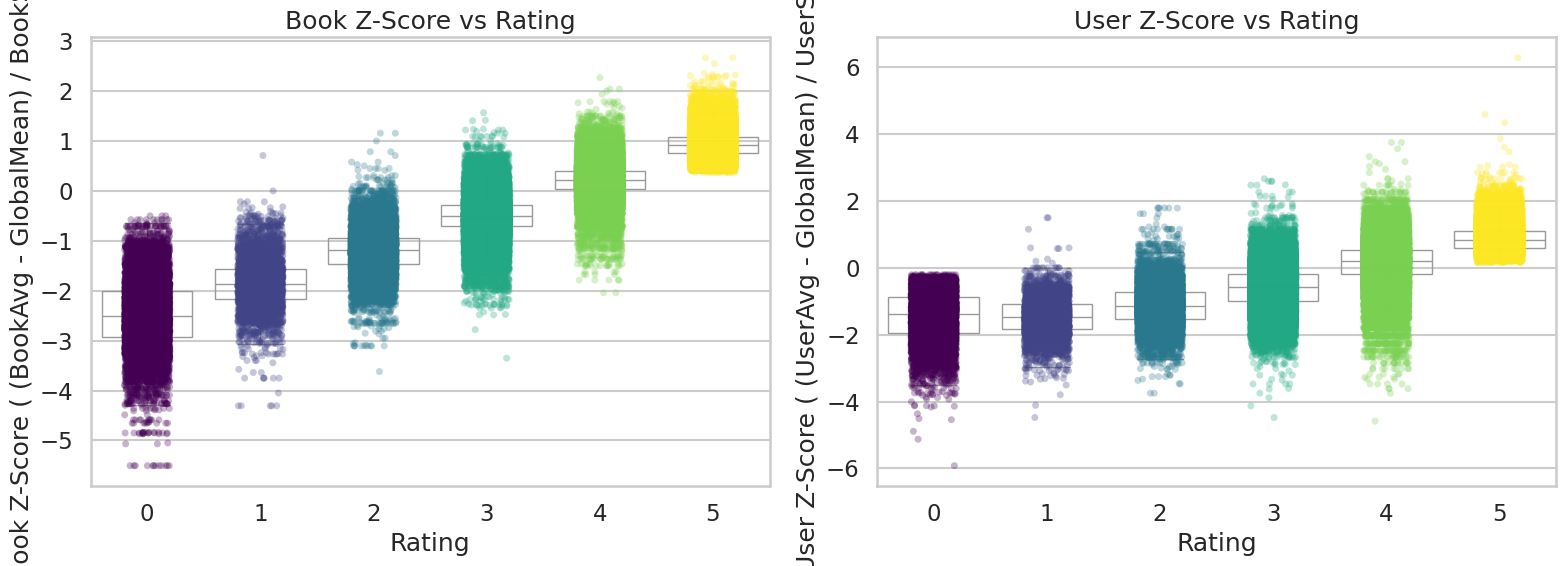

In [54]:

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Book Z-score vs Rating
sns.stripplot(ax=axes[0], x='rating', y='bookID_zscore', data=train_inter, hue='rating', palette='viridis', jitter=0.2, alpha=0.3, legend=False)
axes[0].set_title('Book Z-Score vs Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Book Z-Score ( (BookAvg - GlobalMean) / BookStd )')
sns.boxplot(ax=axes[0], x='rating', y='bookID_zscore', data=train_inter, color='white', showfliers=False, boxprops={'facecolor':'None'})

# Plot 2: User Z-score vs Rating
sns.stripplot(ax=axes[1], x='rating', y='userID_zscore', data=train_inter, hue='rating', palette='viridis', jitter=0.2, alpha=0.3, legend=False)
axes[1].set_title('User Z-Score vs Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('User Z-Score ( (UserAvg - GlobalMean) / UserStd )')
sns.boxplot(ax=axes[1], x='rating', y='userID_zscore', data=train_inter, color='white', showfliers=False, boxprops={'facecolor':'None'})

plt.tight_layout()
plt.savefig('zscore_plots.png')

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# --- CONFIGURATION ---
TRAIN_FILE = 'train_cat_data.csv'
TEST_FILE = 'test_cat_data.csv' # Using the new CSV you uploaded
OUTPUT_FILE = 'predictions_Category.csv'

# --- 1. LOAD DATA ---
print("1. Loading Data...")
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

# Handle column naming differences (just in case)
text_col_train = 'review_text' if 'review_text' in train_df.columns else 'text'
text_col_test = 'review_text' if 'review_text' in test_df.columns else 'text'

# Handle Label Mapping
catDict = {
  "children": 0,
  "comics_graphic": 1,
  "fantasy_paranormal": 2,
  "mystery_thriller_crime": 3,
  "young_adult": 4
}

# If training labels are strings ("children"), map them to numbers
if train_df['genre'].dtype == 'O':
    train_df['label'] = train_df['genre'].map(catDict)
else:
    train_df['label'] = train_df['genre']

# Drop any rows that didn't map correctly
train_df = train_df.dropna(subset=['label'])

# --- 2. VECTORIZATION (The "Unique Words" Step) ---
print("2. Extracting Distinctive Words (TF-IDF)...")

# This finds unique words AUTOMATICALLY.
# ngram_range=(1, 2) means it looks for "comic" AND "comic book"
vectorizer = TfidfVectorizer(
    max_features=25000,      # Keep top 25,000 distinctive words/phrases
    ngram_range=(1, 2),      # Unigrams and Bigrams
    stop_words='english',    # Remove noise like "the", "and"
    sublinear_tf=True        # smooths counts (logarithmic)
)

# Learn vocabulary from Train, apply to Test
X_train = vectorizer.fit_transform(train_df[text_col_train].fillna(""))
X_test = vectorizer.transform(test_df[text_col_test].fillna(""))
y_train = train_df['label']

# --- 3. TRAINING ---
print("3. Training Model...")

# LinearSVC is the best model for this.
# class_weight='balanced' IS CRITICAL -> It stops the "Everything is Fantasy" bug
model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
model.fit(X_train, y_train)

# --- 4. PREDICTION ---
print("4. Predicting...")
predictions = model.predict(X_test)

# --- 5. SAVING ---
submission = pd.DataFrame({
    'userID': test_df['user_id'],
    'reviewID': test_df['review_id'],
    'prediction': predictions.astype(int)
})

submission.to_csv(OUTPUT_FILE, index=False)
print(f"DONE! Saved to {OUTPUT_FILE}")

1. Loading Data...
2. Extracting Distinctive Words (TF-IDF)...


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load the data
df = pd.read_csv('train_cat_data.csv')

# 2. Define a function to get top words
def get_top_n_words(corpus, n=20):
    # Initialize vectorizer, removing English stop words
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    
    # Sum word counts across all documents
    sum_words = bag_of_words.sum(axis=0) 
    
    # Create a list of (word, frequency) tuples
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    
    # Sort by frequency (descending)
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[n:n*2]

# 3. Iterate through each unique genre
for genre in df['genre'].unique():
    print(f"\n=== {genre} ===")
    
    # Filter text for this genre
    subset_text = df[df['genre'] == genre]['review_text'].dropna()
    
    # Get and print top words
    top_words = get_top_n_words(subset_text)
    for word, freq in top_words:
        print(f"{word}: {freq}")


=== mystery_thriller_crime ===
book: 34440
read: 19167
story: 15854
like: 11829
just: 10690
characters: 10552
really: 9679
series: 9305
good: 8802
mystery: 7573
books: 7518
time: 7108
reading: 6630
novel: 6326
love: 5877
way: 5840
character: 5742
author: 5699
great: 5508
did: 5363

=== comics_graphic ===
story: 4828
book: 3923
like: 3376
read: 3365
really: 2921
just: 2802
series: 2357
volume: 1970
good: 1920
characters: 1880
art: 1830
love: 1725
graphic: 1587
time: 1578
great: 1503
comic: 1499
novel: 1341
way: 1299
think: 1239
little: 1231

=== young_adult ===
book: 38595
read: 16503
like: 15951
just: 14492
story: 14183
really: 14024
love: 11150
characters: 9044
didn: 6917
good: 6782
think: 6745
way: 6710
time: 6374
know: 6330
loved: 6248
reading: 6222
life: 6101
did: 5927
character: 5737
don: 5736

=== fantasy_paranormal ===
book: 59559
story: 28330
read: 28030
like: 22252
series: 20640
just: 20236
really: 18541
characters: 17694
love: 16287
books: 12427
world: 12386
good: 12006
time

In [12]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# 1. Load Data
df = pd.read_csv('train_cat_data.csv')

# 2. Define generic words to strictly exclude
# These are high-frequency words that don't help distinguish genres
generic_words = [
    'book', 'books', 'story', 'read', 'reading', 'reads', 'reader',
    'like', 'liked', 'just', 'really', 'good', 'great', 'bad',
    'did', 'time', 'love', 'loved', 'think', 'know', 'way', 
    'character', 'characters', 'author', 'series', 'plot',
    'didn', 'don', 've', 'wa', 'ha', 'novel', 'review', 'writing',
    'people', 'make', 'going', 'want', 'got', 'little', 'thing', 
    'things', 'say', 'end', 'ending', 'page', 'pages', 'bit',
    'feel', 'felt', 'actually', 'sure', 'better', 'best', 'world', 'life',
    'lot', 'new', 'enjoyed', 'interesting','la','que','does','doesn','make',
     'different','favorite','was','wasn','written','makes','ll','thought',
      'come','year','old','quite','right','definitely','en','kind','look'
       'times','away','kinds','day','man','main','romance','years','di','el',
        'wait','stories','times','couldn','long','real','fan','far','kept','es','friend' # Added based on initial test run
]

# Combine with standard English stop words
custom_stop_words = list(ENGLISH_STOP_WORDS) + generic_words

# 3. Group text by category
# We treat all reviews in a single category as one giant "document"
grouped_text = df.groupby('genre')['review_text'].apply(lambda x: " ".join(x.dropna().astype(str)))

# 4. TF-IDF Vectorization
# This calculates the "uniqueness" score for each word per category
tfidf = TfidfVectorizer(stop_words=custom_stop_words, max_features=10000)
tfidf_matrix = tfidf.fit_transform(grouped_text)

# 5. Extract and print top unique words
feature_names = tfidf.get_feature_names_out()

print("=== Top 20 Distinctive Words per Category (TF-IDF) ===\n")

for i, genre in enumerate(grouped_text.index):
    # Get the row for this genre from the matrix
    row = tfidf_matrix.getrow(i).toarray()[0]
    
    # Sort indices by score (descending)
    top_indices = row.argsort()[::-1][:-20]
    
    # Get the actual words
    top_words = [feature_names[idx] for idx in top_indices]
    
    print(f"--- {genre} ---")
    print(", ".join(top_words))
    print("")

=== Top 20 Distinctive Words per Category (TF-IDF) ===

--- children ---
children, illustrations, kids, fun, young, school, child, family, readers, cute, girl, picture, friends, boy, parents, beautiful, help, words, text, wonderful, animals, home, funny, simple, enjoy, work, pictures, mother, kid, perfect, library, look, big, especially, recommend, stars, grade, dog, house, learn, tale, nice, girls, age, gets, short, sweet, middle, aloud, use, used, copy, adult, pretty, son, art, adults, having, hard, small, remember, older, idea, isn, message, looking, cat, happy, students, easy, understand, father, goes, probably, younger, need, told, point, tell, adventure, daughter, comes, maybe, able, fact, place, getting, play, said, trying, baby, wants, class, loves, true, let, night, making, lives, movie, second, wanted, animal, amazing, lovely, ages, learning, bear, course, yang, takes, mom, style, shows, teacher, classic, mr, boys, important, try, childhood, com, chapter, adventures, christma

In [13]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ================= CONFIGURATION =================
# REPLACE 'training_data.csv' WITH YOUR ACTUAL TRAINING FILE NAME
TRAIN_FILE = 'train_cat_data.csv' 

# REPLACE 'genre' WITH THE NAME OF THE COLUMN CONTAINING THE ACTUAL LABELS
LABEL_COLUMN = 'genre' 

# REPLACE 'review_text' WITH THE NAME OF THE COLUMN CONTAINING THE TEXT
TEXT_COLUMN = 'review_text'
# =================================================

# Load Data
try:
    df = pd.read_csv(TRAIN_FILE)
    print(f"Successfully loaded {len(df)} rows from {TRAIN_FILE}")
except FileNotFoundError:
    print(f"Error: Could not find file '{TRAIN_FILE}'. Please check the filename.")
    exit()

# ================= YOUR MODEL LOGIC =================
keywords = {
    'children': [
        'children', 'child', 'kid', 'kids', 'picture book', 'bedtime', 'toddler',
        'baby', 'preschool', 'kindergarten', 'illustrations', 'board book',
        'middle grade', 'scary', 'kinderbuch', 'enfant', 'niños', 'bilderbuch',
        'classic', 'fairy', 'sweet story','beautiful','wonderful'
    ],
    'comics_graphic': [
        'comic', 'comics', 'graphic novel', 'manga', 'anime', 'panel', 'artwork',
        'illustrator', 'volume', 'visual', 'art', 'strip', 'superhero', 'bande dessinee', 
        'bd', 'Wolverine','marvel','batman','volumes','graphic'
    ],
    'fantasy_paranormal': [
        'fantasy', 'paranormal', 'magic', 'wizard', 'witch', 'dragon', 'vampire',
        'werewolf', 'supernatural', 'fae', 'elf', 'curse', 'ghost', 'demon',
        'god', 'goddess', 'mythology', 'kingdom', 'prophecy', 'immortal', 
        'fantasia', 'fantasie', 'sorcerer', 'shifter','novella','dark',
    ],
    'mystery_thriller_crime': [
        'mystery', 'thriller', 'crime', 'murder', 'detective', 'police', 'investigation',
        'suspense', 'killer', 'suspect', 'spy', 'noir', 'whodunit', 'agent',
        'case', 'lawyer', 'fbi', 'forensic', 'krimi', 'misterio', 'mystere', 'policier',
        'creepy','gross','scary','woman','death','action'
    ],
    'young_adult': [
        'young adult', 'ya', 'teen', 'teenager', 'high school', 'romance', 'coming of age',
        'dystopian', 'dystopia', 'angst', 'love triangle', 'sixteen', 'seventeen',
        'boyfriend', 'girlfriend', 'crush', 'prom', 'jugendbuch','hug','kiss','hype'
    ]
}

def predict_category(text):
    if not isinstance(text, str):
        return 'fantasy_paranormal' 

    text = text.lower()
    scores = {cat: 0 for cat in keywords}

    for cat, words in keywords.items():
        for word in words:
            # Using word boundaries for short words
            if len(word) <= 3:
                 if re.search(r'\b' + re.escape(word) + r'\b', text):
                     scores[cat] += 1
            else:
                if word in text:
                    scores[cat] += 1

    max_cat = max(scores, key=scores.get)
    max_val = scores[max_cat]

    if max_val == 0:
        return 'fantasy_paranormal'
    
    return max_cat
# ====================================================

# 1. Run Prediction
print("Running predictions on training data...")
df['predicted_label'] = df[TEXT_COLUMN].apply(predict_category)

# 2. Calculate Metrics
accuracy = accuracy_score(df[LABEL_COLUMN], df['predicted_label'])
print(f"\n=== Overall Accuracy: {accuracy:.2%} ===\n")

print("=== Classification Report ===")
print(classification_report(df[LABEL_COLUMN], df['predicted_label']))

# 3. Confusion Matrix
print("=== Confusion Matrix ===")
cm = confusion_matrix(df[LABEL_COLUMN], df['predicted_label'], labels=list(keywords.keys()))
cm_df = pd.DataFrame(cm, index=keywords.keys(), columns=keywords.keys())
print(cm_df)

# 4. Error Analysis - See WHY it failed
print("\n=== Error Analysis: Sample Misclassifications ===")
# Find rows where prediction didn't match label
errors = df[df[LABEL_COLUMN] != df['predicted_label']]

if not errors.empty:
    # Show 3 examples for each category
    for cat in keywords.keys():
        cat_errors = errors[errors[LABEL_COLUMN] == cat]
        if not cat_errors.empty:
            print(f"\n[Actual Category: {cat}] - Misclassified Examples:")
            # Sample up to 3 errors
            sample = cat_errors.head(3)
            for idx, row in sample.iterrows():
                print(f" -> Predicted: {row['predicted_label']}")
                print(f" -> Text Snippet: {str(row[TEXT_COLUMN])[:150]}...")
else:
    print("Perfect accuracy! No errors to analyze.")

Successfully loaded 100000 rows from train_cat_data.csv
Running predictions on training data...

=== Overall Accuracy: 52.94% ===

=== Classification Report ===
                        precision    recall  f1-score   support

              children       0.33      0.59      0.43      8946
        comics_graphic       0.67      0.56      0.61      7390
    fantasy_paranormal       0.50      0.67      0.57     36235
mystery_thriller_crime       0.66      0.49      0.56     27246
           young_adult       0.65      0.28      0.39     20183

              accuracy                           0.53    100000
             macro avg       0.56      0.52      0.51    100000
          weighted avg       0.57      0.53      0.52    100000

=== Confusion Matrix ===
                        children  comics_graphic  fantasy_paranormal  \
children                    5314             236                2950   
comics_graphic               841            4134                1834   
fantasy_paranormal 

In [3]:
import pandas as pd
import re

# Load the dataset
df = pd.read_csv('test_cat_predictions.csv')

# Expanded keyword dictionary with scoring capability
keywords = {
    'children': [
        'children', 'child', 'kid', 'kids', 'picture book', 'bedtime', 'toddler',
        'baby', 'preschool', 'kindergarten', 'illustrations', 'board book',
        'middle grade', 'scary', 'kinderbuch', 'enfant', 'niños', 'bilderbuch'
    ],
    'comics_graphic': [
        'comic', 'comics', 'graphic novel', 'manga', 'anime', 'panel', 'artwork',
        'illustrator', 'volume', 'visual', 'art', 'strip', 'superhero', 'bande dessinee', 'bd'
    ],
    'fantasy_paranormal': [
        'fantasy', 'paranormal', 'magic', 'wizard', 'witch', 'dragon', 'vampire',
        'werewolf', 'supernatural', 'fae', 'elf', 'curse', 'ghost', 'demon',
        'god', 'goddess', 'mythology', 'kingdom', 'prophecy', 'immortal', 
        'fantasia', 'fantasie', 'sorcerer', 'shifter'
    ],
    'mystery_thriller_crime': [
        'mystery', 'thriller', 'crime', 'murder', 'detective', 'police', 'investigation',
        'suspense', 'killer', 'suspect', 'spy', 'noir', 'whodunit', 'agent',
        'case', 'lawyer', 'fbi', 'forensic', 'krimi', 'misterio', 'mystere', 'policier'
    ],
    'young_adult': [
        'young adult', 'ya', 'teen', 'teenager', 'high school', 'romance', 'coming of age',
        'dystopian', 'dystopia', 'angst', 'love triangle', 'sixteen', 'seventeen',
        'boyfriend', 'girlfriend', 'crush', 'prom', 'jugendbuch'
    ]
}

def predict_category(text):
    if not isinstance(text, str):
        return 'fantasy_paranormal' # Default category

    text = text.lower()
    scores = {cat: 0 for cat in keywords}

    # Count keyword occurrences
    for cat, words in keywords.items():
        for word in words:
            # Use word boundaries for short words to avoid partial matches (e.g. 'ya' in 'layer')
            if len(word) <= 3:
                 if re.search(r'\b' + re.escape(word) + r'\b', text):
                     scores[cat] += 1
            else:
                if word in text:
                    scores[cat] += 1

    # Find category with the highest score
    max_cat = max(scores, key=scores.get)
    max_val = scores[max_cat]

    # Fallback to default if no keywords match
    if max_val == 0:
        return 'fantasy_paranormal'
    
    return max_cat

# Apply prediction
df['prediction'] = df['review_text'].apply(predict_category)
catDict = {
  "children": 0,
  "comics_graphic": 1,
  "fantasy_paranormal": 2,
  "mystery_thriller_crime": 3,
  "young_adult": 4
}
# Save to CSV
output_df = df[['user_id', 'review_id', 'prediction']]
output_df['prediction'] = output_df['prediction'].map(catDict)
output_df.to_csv('predictions_Category.csv.csv', index=False)

print("Done! Predictions saved.")

Done! Predictions saved.


/tmp/ipykernel_2725/4049151518.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output_df['prediction'] = output_df['prediction'].map(catDict)


In [57]:
print(train_inter.head())
p =pd.read_csv('predictions_Rating.csv')
for r in range(6):
    # Filter for interactions with this rating
    subset = train_inter[train_inter['rating'] == r]
    
    # Calculate Q1 (25%) and Q3 (75%)
    q1 = subset['bookID_zscore'].quantile(0.25)
    q3 = subset['bookID_zscore'].quantile(0.75)
    books = subset[(subset['bookID_zscore']>=q1)&(subset['bookID_zscore']<=q3)]['bookID'].unique()
    #train_inter[r] = (q1, q3)
    print(f"Rating {r}: Z-score range [{q1:.3f}, {q3:.3f}]")
    print(f"found {p[p['bookID'].isin(books)].shape[0]} matches")

      userID     bookID  rating  book_interactions  bookID_zscore  \
0  u67805239  b61372131       4                463       0.478933   
1  u54531895  b75189008       4                 10      -0.114208   
2  u76549666  b75446982       4                 14       0.699195   
3  u03186275  b23482469       2                 93      -1.169871   
4  u21322233  b09979253       3                111      -0.540299   

   user_interactions  userID_zscore  user_mean  user_median  user_mode  
0                 18       1.668467   1.055556          0.0          0  
1                  7       0.000000   4.000000          4.0          4  
2                 20       0.430649   3.650000          4.0          3  
3                 10      -0.870572   2.800000          2.5          2  
4                  9      -0.894427   4.000000          4.0          5  
Rating 0: Z-score range [-2.937, -2.011]
found 3749 matches
Rating 1: Z-score range [-2.163, -1.557]
found 2601 matches
Rating 2: Z-score range [-1

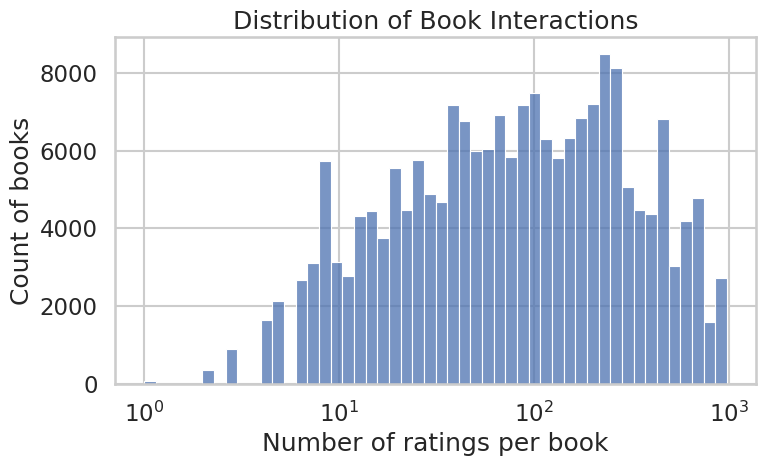

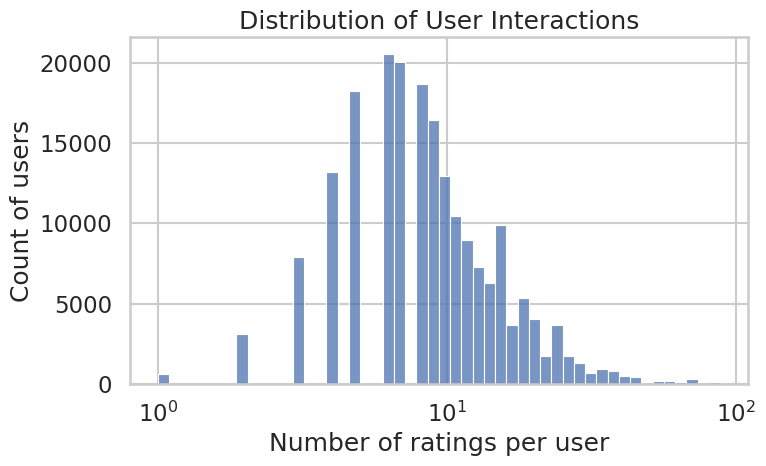

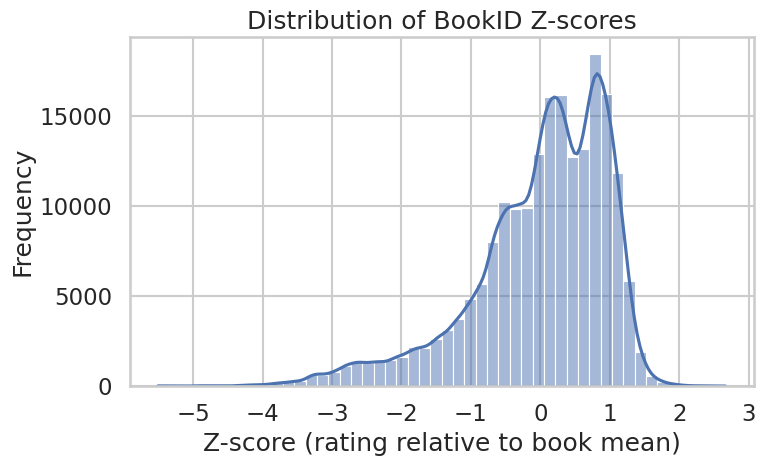

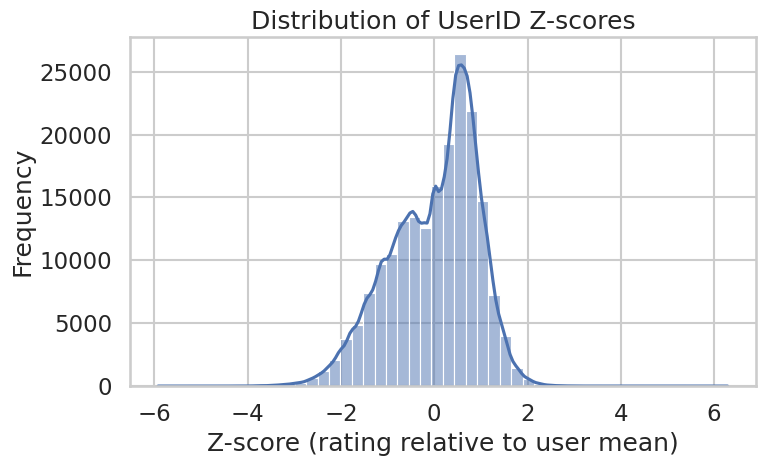

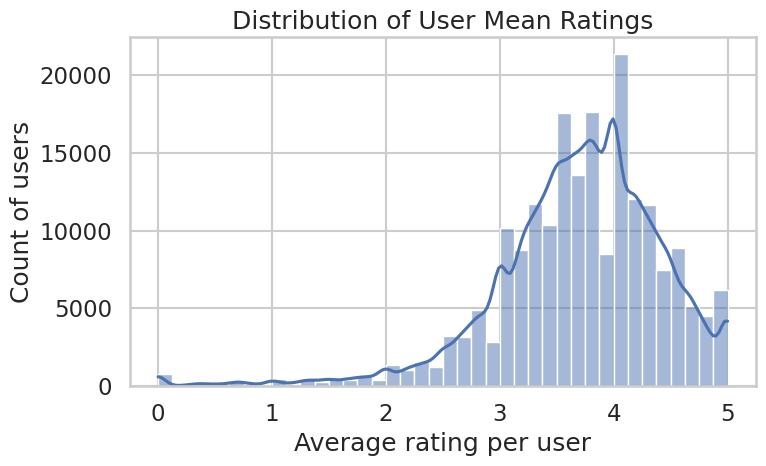

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

# 1. Histogram of book_interactions
plt.figure(figsize=(8,5))
sns.histplot(train_inter["book_interactions"], bins=50, log_scale=True)
plt.title("Distribution of Book Interactions")
plt.xlabel("Number of ratings per book")
plt.ylabel("Count of books")
plt.tight_layout()
plt.show()

# 2. Histogram of user_interactions
plt.figure(figsize=(8,5))
sns.histplot(train_inter["user_interactions"], bins=50, log_scale=True)
plt.title("Distribution of User Interactions")
plt.xlabel("Number of ratings per user")
plt.ylabel("Count of users")
plt.tight_layout()
plt.show()

# 3. Distribution of bookID_zscore
plt.figure(figsize=(8,5))
sns.histplot(train_inter["bookID_zscore"].dropna(), bins=50, kde=True)
plt.title("Distribution of BookID Z-scores")
plt.xlabel("Z-score (rating relative to book mean)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4. Distribution of userID_zscore
plt.figure(figsize=(8,5))
sns.histplot(train_inter["userID_zscore"].dropna(), bins=50, kde=True)
plt.title("Distribution of UserID Z-scores")
plt.xlabel("Z-score (rating relative to user mean)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 5. Histogram of user_mean ratings
plt.figure(figsize=(8,5))
sns.histplot(train_inter["user_mean"], bins=40, kde=True)
plt.title("Distribution of User Mean Ratings")
plt.xlabel("Average rating per user")
plt.ylabel("Count of users")
plt.tight_layout()
plt.show()

In [ ]:
def predictRating_visual_tuned(user, item, 
                               ratingMean, 
                               userAverages, itemAverages, 
                               reviewsPerUser, usersPerItem, 
                               k_user=5, k_item=10): # Lower k_item because Plot 5 shows books have plenty of data
    
    # -------------------------------------------------------
    # PARAMETERS DERIVED FROM PLOTS
    # -------------------------------------------------------
    USER_ANCHOR = 4.0       # From Plot 1: Users naturally center at 4.0, not 3.7
    HATER_THRESHOLD = 2.0   # From Plot 1: The tail drops off at 2.0
    SUPER_BOOK_THRESHOLD = 4.3 # From Plot 4: The second peak represents elite books
    
    # -------------------------------------------------------
    # 1. DATA RETRIEVAL
    # -------------------------------------------------------
    mu = ratingMean
    
    u_avg = userAverages.get(user, USER_ANCHOR) # Default new users to 4.0
    num_user_reviews = len(reviewsPerUser.get(user, []))
    
    i_avg = itemAverages.get(item, mu)
    num_item_raters = len(usersPerItem.get(item, set()))
    
    # -------------------------------------------------------
    # 2. BOOK BIAS CALCULATION (The "Bimodal" Fix)
    # -------------------------------------------------------
    # Plot 5 shows books have data, so we trust item_avg highly (low k_item)
    b_i = (i_avg - mu) * (num_item_raters / (num_item_raters + k_item))
    
    # HEURISTIC A: The "Super Book" Snap
    # If the book is in that upper peak of Plot 4, we push it towards 5
    if i_avg >= SUPER_BOOK_THRESHOLD:
        return 5.0

    # -------------------------------------------------------
    # 3. USER BIAS CALCULATION (The "Optimist" Fix)
    # -------------------------------------------------------
    # Plot 1 shows users Center at 4.0. 
    # We calculate bias relative to 4.0, NOT the global mean.
    # This helps the "Low N" users in Plot 3 start at 4.0
    b_u_raw = u_avg - USER_ANCHOR 
    b_u = b_u_raw * (num_user_reviews / (num_user_reviews + k_user))
    
    # -------------------------------------------------------
    # 4. FINAL COMBINATION & HEURISTIC B
    # -------------------------------------------------------
    
    # HEURISTIC B: The "True Hater" (from Plot 1 tail)
    if u_avg < HATER_THRESHOLD:
        # These people live in a different distribution. 
        # We predict their average directly, ignoring the book's quality.
        prediction = u_avg 
    else:
        # Standard Optimist Calculation
        # We use USER_ANCHOR as the base, not mu
        prediction = USER_ANCHOR + b_u + b_i

    # Clip to valid range
    if prediction > 5: prediction = 5
    if prediction < 0: prediction = 0
        
    return prediction



Loading data...
Dataset: 27945 Users, 6688 Books, 200000 Interactions
Building Sparse Matrix...
Running SVD with k=50...
SVD Complete.
Generating predictions for Test Set...
Accuracy (rounded): 0.3652
RMSE: 1.2959


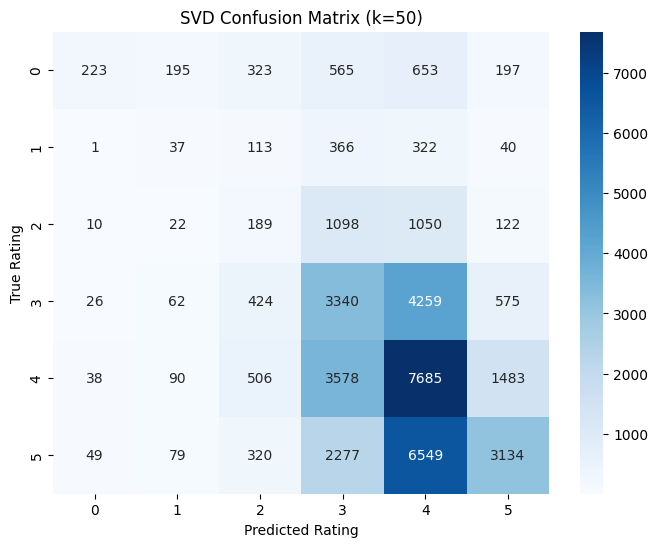

In [ ]:
# ... (Assume you have run the SVD code and have 'U', 'sigma', 'Vt', 'user_means', 'global_mean')

# 1. Define the Helper to get SVD Scores quickly
def get_svd_score_vectorized(user_codes, book_codes):
    """
    Optimized way to grab SVD predictions for a list of users/books
    """
    # Initialize with global mean
    preds = np.full(len(user_codes), global_mean)
    
    # Find which indices are valid (known users/books)
    # We need to ensure we don't access U or Vt out of bounds
    valid_mask = (user_codes < U.shape[0]) & (book_codes < Vt.shape[1])
    
    # Get the vectors for valid entries
    u_vecs = U[user_codes[valid_mask]]
    b_vecs = Vt.T[book_codes[valid_mask]] # Transpose Vt to get (Books, k)
    
    # Dot product of rows: sum(u * b, axis=1)
    # This calculates the interaction term
    interaction = np.sum(u_vecs @ sigma * b_vecs, axis=1)
    
    # Add user means
    u_means = user_means[user_codes[valid_mask]]
    preds[valid_mask] = interaction + u_means
    
    return preds

# 2. Prepare the Data for Random Forest
# Recalculate the basic features
df['user_avg'] = df.groupby('userID')['rating'].transform('mean')
df['book_avg'] = df.groupby('bookID')['rating'].transform('mean')

# Generate the SVD Feature (The "Hybrid" Step)
# We use the mappings we created earlier
df['svd_rating'] = get_svd_score_vectorized(df['user_codes'].values, df['book_codes'].values)

# 3. Split (Stratify is key for imbalanced data)
X = df[['user_avg', 'book_avg', 'svd_rating']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train Random Forest (With the SVD feature included!)
# We bring back class_weight='balanced' to fix the "0" and "1" prediction problem
rf_model = RandomForestClassifier(n_estimators=100, 
                                  class_weight='balanced', 
                                  random_state=42, 
                                  n_jobs=-1)

print("Training Hybrid Model (RF + SVD)...")
rf_model.fit(X_train, y_train)

# 5. Evaluate
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
unique_labels = sorted(df['rating'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels)
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.title('Confusion Matrix: Hybrid (SVD + Random Forest)')
plt.show()

# Check Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importances)

Calculating Modes (this takes a second)...
Global Mode is: 4
Training on Modes...

=== Accuracy with Mode: 0.4112 ===


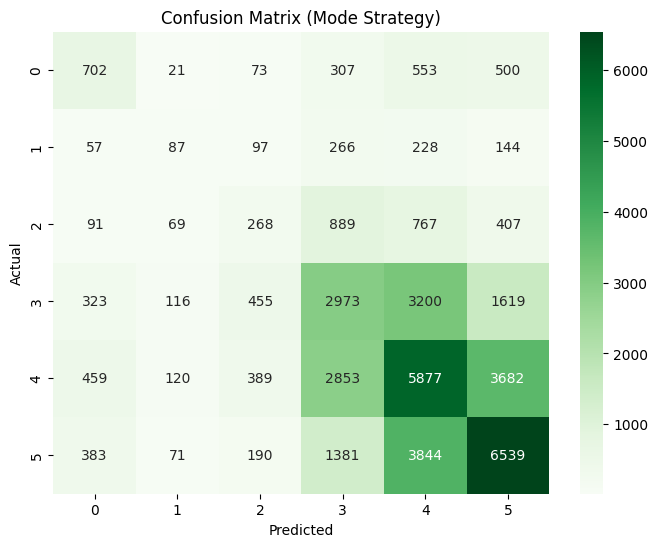

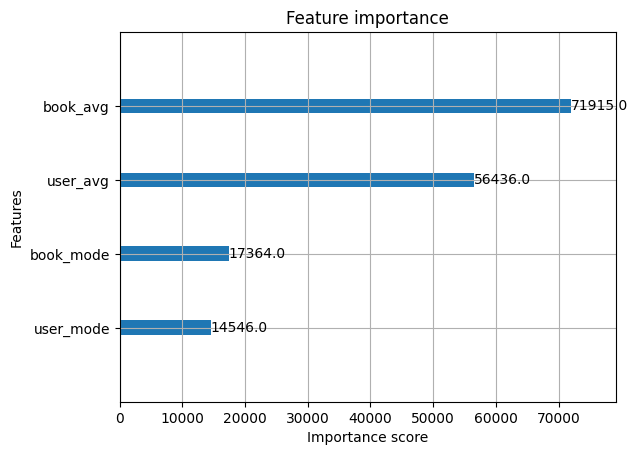

In [37]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('train_Interactions.csv')

# 2. Split Data (CRITICAL: Split first so we don't cheat on the mode)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['rating'])

# 3. Feature Engineering: The MODE Strategy
print("Calculating Modes (this takes a second)...")

# Helper to get mode (handles cases with ties by taking the first one)
def get_mode_value(x):
    return x.mode().iloc[0] if not x.mode().empty else 4

# Calculate User Mode
user_mode = train_df.groupby('userID')['rating'].apply(get_mode_value).to_dict()
# Calculate Book Mode
book_mode = train_df.groupby('bookID')['rating'].apply(get_mode_value).to_dict()

# Calculate Global Mode (Fallback)
global_mode = train_df['rating'].mode()[0]

print(f"Global Mode is: {global_mode}")

# 4. Map Features
# If user/book is new (Cold Start), fall back to Global Mode
train_df['user_mode'] = train_df['userID'].map(user_mode).fillna(global_mode)
train_df['book_mode'] = train_df['bookID'].map(book_mode).fillna(global_mode)

test_df['user_mode'] = test_df['userID'].map(user_mode).fillna(global_mode)
test_df['book_mode'] = test_df['bookID'].map(book_mode).fillna(global_mode)

# Keep the averages too (sometimes the blend helps)
train_df['user_avg'] = train_df.groupby('userID')['rating'].transform('mean')
train_df['book_avg'] = train_df.groupby('bookID')['rating'].transform('mean')

# Just simple fillna for averages on test set (simplified for brevity)
test_df['user_avg'] = test_df['userID'].map(train_df.groupby('userID')['rating'].mean()).fillna(train_df['rating'].mean())
test_df['book_avg'] = test_df['bookID'].map(train_df.groupby('bookID')['rating'].mean()).fillna(train_df['rating'].mean())

# 5. Train XGBoost Classifier
# We focus heavily on the MODES now
features = ['user_mode', 'book_mode', 'user_avg', 'book_avg']

model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    objective='multi:softmax', # Hard classification
    num_class=6,
    n_jobs=-1,
    random_state=42
)

print("Training on Modes...")
model.fit(train_df[features], train_df['rating'])

# 6. Evaluate
y_pred = model.predict(test_df[features])

acc = accuracy_score(test_df['rating'], y_pred)
print(f"\n=== Accuracy with Mode: {acc:.4f} ===")

# Visualization
cm = confusion_matrix(test_df['rating'], y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Mode Strategy)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Check if Mode beat Mean in importance
xgb.plot_importance(model, importance_type='weight')
plt.show()

Calculating statistics...
Identified 570 'Hater' users.
Running predictions...
Accuracy: 0.3772


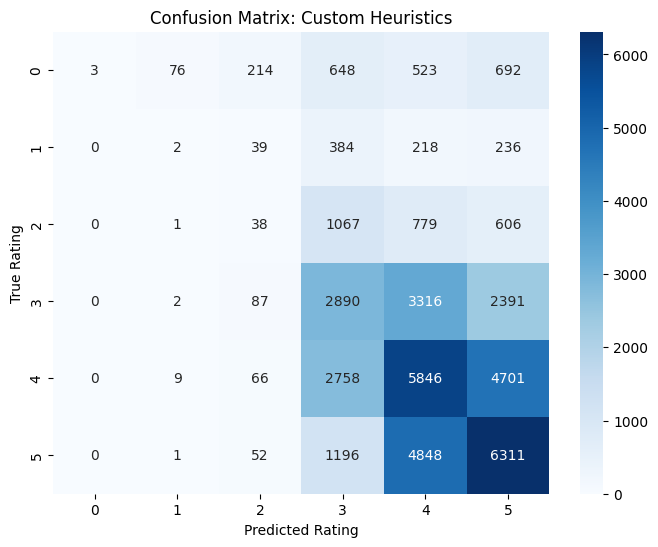

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Load Data
df = pd.read_csv('train_Interactions.csv')

# 2. Split Data (Standard 80/20 split)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['rating'])

# ---------------------------------------------------------
# 3. PRE-COMPUTE STATISTICS (Training Data Only)
# ---------------------------------------------------------
print("Calculating statistics...")

# A. Basic Stats
ratingMean = train_df['rating'].mean()
reviewsPerUser = train_df.groupby('userID')['bookID'].apply(list).to_dict()
usersPerItem = train_df.groupby('bookID')['userID'].apply(set).to_dict()
userAverages = train_df.groupby('userID')['rating'].mean().to_dict()
itemAverages = train_df.groupby('bookID')['rating'].mean().to_dict()

# B. Calculate "Book Mode" for your heuristic
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else None
book_modes = train_df.groupby('bookID')['rating'].apply(get_mode).to_dict()

# C. Identify "Haters" (Users with very low average rating)
# Heuristic: If a user's average is < 2.5, they are a "Hater"
hater_threshold = 1.5
haters_set = set(k for k, v in userAverages.items() if v < hater_threshold)

print(f"Identified {len(haters_set)} 'Hater' users.")

# ---------------------------------------------------------
# 4. YOUR CUSTOM PREDICTION FUNCTION
# ---------------------------------------------------------
def predictRating_tuned(user, item, 
                        ratingMean, 
                        userAverages, itemAverages, 
                        reviewsPerUser, usersPerItem, 
                        book_modes, haters_set,
                        k_user=5, k_item=20):
    
    # 1. Check Heuristic: Is this a "Popular" book? (Mode 4 or 5)
    # You mentioned: "if book mode is 4 or 5 return book mode"
    # We check this FIRST. If you want this rule to be absolute, keep it here.
    b_mode = book_modes.get(item, None)
    if b_mode in [5]:
        # We trust the crowd. If everyone gives it a 5, we predict 5.
        return b_mode

    # 2. Standard Baseline Calculation (mu + bu + bi)
    mu = ratingMean
    
    # User Bias
    num_user_reviews = len(reviewsPerUser.get(user, []))
    u_avg = userAverages.get(user, mu)
    # Regularization formula
    b_u = (u_avg - mu) * (num_user_reviews / (num_user_reviews + k_user))
    
    # Item Bias
    num_item_raters = len(usersPerItem.get(item, set()))
    i_avg = itemAverages.get(item, mu)
    b_i = (i_avg - mu) * (num_item_raters / (num_item_raters + k_item))
    final_rating = mu + b_u + b_i
    return(final_rating)
    # 3. Check Heuristic: Is the user a "Hater"?
    if user in haters_set:
        # You mentioned: "final_rating = 1.5 + bi + bu"
        # This shifts their baseline anchor down significantly
        final_rating = 1.5 + b_u + b_i
    else:
        # Standard calculation
        final_rating = mu + b_u + b_i
        
    # 4. Clip to valid range
    if final_rating > 4.2: final_rating = 5
    if final_rating < 0: final_rating = 0
        
    return final_rating

# ---------------------------------------------------------
# 5. RUN PREDICTIONS
# ---------------------------------------------------------
print("Running predictions...")

predictions = []
for _, row in test_df.iterrows():
    pred = predictRating_tuned(
        row['userID'], 
        row['bookID'], 
        ratingMean, 
        userAverages, 
        itemAverages, 
        reviewsPerUser, 
        usersPerItem,
        book_modes,
        haters_set,
        k_user=5,  # Tune these
        k_item=20
    )
    predictions.append(pred)

# Round predictions for Confusion Matrix
y_pred = [int(round(p)) for p in predictions]
y_true = test_df['rating'].tolist()

# ---------------------------------------------------------
# 6. EVALUATION
# ---------------------------------------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_true, y_pred)
unique_labels = sorted(df['rating'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels)
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.title('Confusion Matrix: Custom Heuristics')
plt.show()

Training Hybrid Model (RF + SVD)...
Accuracy: 0.3709


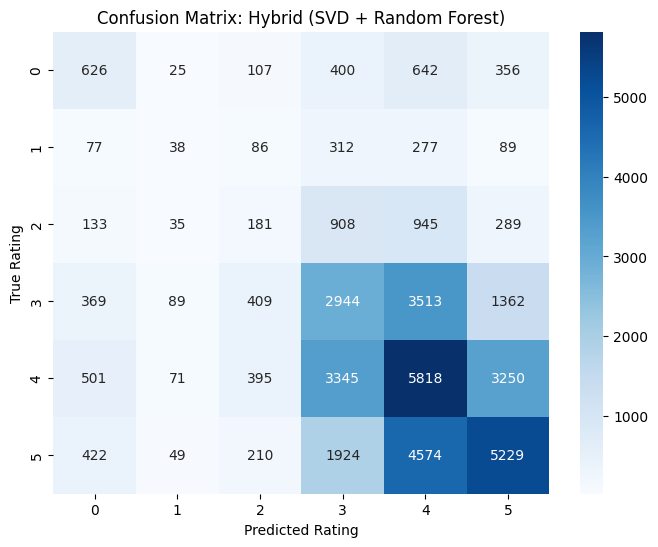

      Feature  Importance
2  svd_rating    0.502404
1    book_avg    0.279644
0    user_avg    0.217952


In [29]:
# ... (Assume you have run the SVD code and have 'U', 'sigma', 'Vt', 'user_means', 'global_mean')

# 1. Define the Helper to get SVD Scores quickly
def get_svd_score_vectorized(user_codes, book_codes):
    """
    Optimized way to grab SVD predictions for a list of users/books
    """
    # Initialize with global mean
    preds = np.full(len(user_codes), global_mean)
    
    # Find which indices are valid (known users/books)
    # We need to ensure we don't access U or Vt out of bounds
    valid_mask = (user_codes < U.shape[0]) & (book_codes < Vt.shape[1])
    
    # Get the vectors for valid entries
    u_vecs = U[user_codes[valid_mask]]
    b_vecs = Vt.T[book_codes[valid_mask]] # Transpose Vt to get (Books, k)
    
    # Dot product of rows: sum(u * b, axis=1)
    # This calculates the interaction term
    interaction = np.sum(u_vecs @ sigma * b_vecs, axis=1)
    
    # Add user means
    u_means = user_means[user_codes[valid_mask]]
    preds[valid_mask] = interaction + u_means
    
    return preds

# 2. Prepare the Data for Random Forest
# Recalculate the basic features
df['user_avg'] = df.groupby('userID')['rating'].transform('mean')
df['book_avg'] = df.groupby('bookID')['rating'].transform('mean')

# Generate the SVD Feature (The "Hybrid" Step)
# We use the mappings we created earlier
df['svd_rating'] = get_svd_score_vectorized(df['user_codes'].values, df['book_codes'].values)

# 3. Split (Stratify is key for imbalanced data)
X = df[['user_avg', 'book_avg', 'svd_rating']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train Random Forest (With the SVD feature included!)
# We bring back class_weight='balanced' to fix the "0" and "1" prediction problem
rf_model = RandomForestClassifier(n_estimators=100, 
                                  class_weight='balanced', 
                                  random_state=42, 
                                  n_jobs=-1)

print("Training Hybrid Model (RF + SVD)...")
rf_model.fit(X_train, y_train)

# 5. Evaluate
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
unique_labels = sorted(df['rating'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels)
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.title('Confusion Matrix: Hybrid (SVD + Random Forest)')
plt.show()

# Check Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importances)

1. Loading Data...
2. Data Split: 160000 Train, 40000 Test
3. Calculating Bias Features...
3b. Calculating Advanced User Stats (Variance/Kurtosis)...


/tmp/ipykernel_504264/4053982256.py:56: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return kurtosis(x)


4. Running SVD (Matrix Factorization)...
5. Training XGBoost...
6. Evaluating...

=== Final Results ===
Accuracy: 0.3735
RMSE:     1.4679


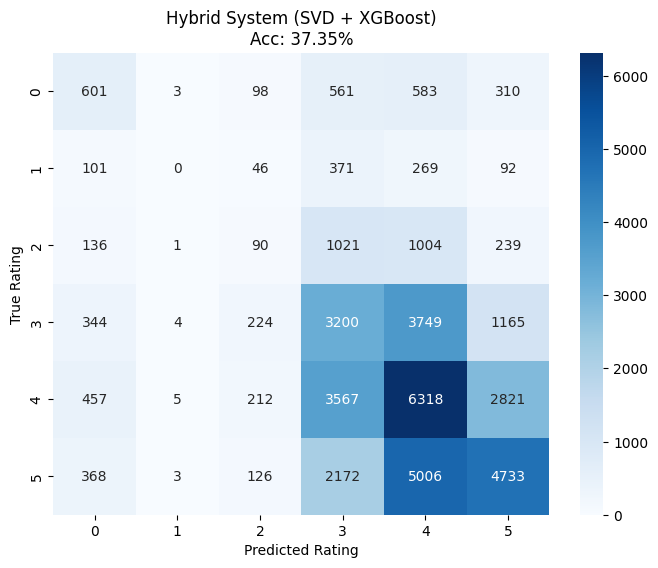

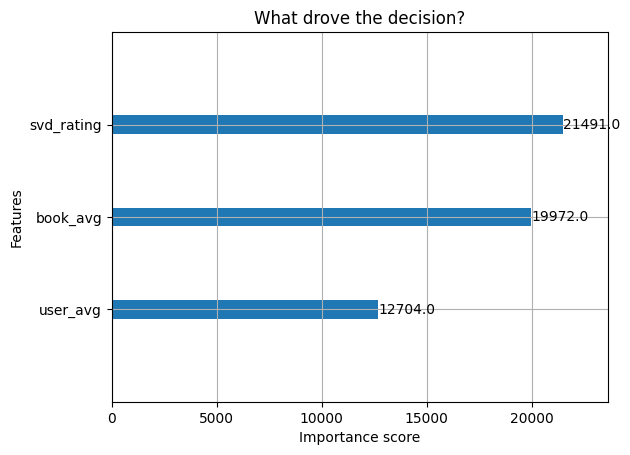

In [34]:
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load and Preprocess
# ==========================================
print("1. Loading Data...")
df = pd.read_csv('train_Interactions.csv')

# Convert IDs to categorical codes (integers) for matrix operations
# We do this on the full dataset to ensure consistent encoding
df['user_codes'] = df['userID'].astype("category").cat.codes
df['book_codes'] = df['bookID'].astype("category").cat.codes

# ==========================================
# 2. Train / Test Split
# ==========================================
# We split NOW. We must calculate averages and SVD *only* on Train data
# to prevent data leakage (cheating).
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['rating'])
print(f"2. Data Split: {len(train_df)} Train, {len(test_df)} Test")

# ==========================================
# 3. Feature Engineering: Statistical Averages
# ==========================================
print("3. Calculating Bias Features...")
# Global Average
global_mean = train_df['rating'].mean()

# User Average (Bias)
user_avg = train_df.groupby('userID')['rating'].mean().to_dict()
# Book Average (Bias)
book_avg = train_df.groupby('bookID')['rating'].mean().to_dict()

# Map these features to Train and Test
# Fill NaNs with global_mean (for Cold Start: new users/books in test set)
train_df['user_avg'] = train_df['userID'].map(user_avg).fillna(global_mean)
train_df['book_avg'] = train_df['bookID'].map(book_avg).fillna(global_mean)

test_df['user_avg'] = test_df['userID'].map(user_avg).fillna(global_mean)
test_df['book_avg'] = test_df['bookID'].map(book_avg).fillna(global_mean)
from scipy.stats import kurtosis, skew

print("3b. Calculating Advanced User Stats (Variance/Kurtosis)...")

# Function to safely calculate kurtosis (handles users with too few ratings)
def get_kurtosis(x):
    if len(x) < 4: return 0 # Not enough data for valid kurtosis
    return kurtosis(x)

# Calculate Variance (Spread) and Kurtosis (Peakedness)
user_stats = train_df.groupby('userID')['rating'].agg(['std', get_kurtosis])
user_stats.columns = ['user_std', 'user_kurtosis']

# Fill NaNs (Users with 1 rating have NaN std)
user_stats['user_std'] = user_stats['user_std'].fillna(0)

# Map to Train/Test
# We join these new columns to the dataframes
train_df = train_df.join(user_stats, on='userID')
test_df = test_df.join(user_stats, on='userID')

# Handle Cold Start (Users in test not in train get 0 variance)
test_df['user_std'] = test_df['user_std'].fillna(0)
test_df['user_kurtosis'] = test_df['user_kurtosis'].fillna(0)

# Update Feature List
features = ['user_avg', 'book_avg', 'svd_rating', 'user_std', 'user_kurtosis']
# ==========================================
# 4. Feature Engineering: SVD (Latent Factors)
# ==========================================
print("4. Running SVD (Matrix Factorization)...")

# A. Build Sparse Matrix (Train Data Only)
num_users = df['user_codes'].max() + 1
num_books = df['book_codes'].max() + 1

R_train = csr_matrix((train_df['rating'], (train_df['user_codes'], train_df['book_codes'])), 
                     shape=(num_users, num_books))

# B. Normalize (Subtract User Means) - CAST TO FLOAT TO AVOID ERROR
R_demeaned = R_train.astype(float)
train_user_means = np.zeros(num_users)

# Fast calculation of row means for sparse matrix
user_sums = R_train.sum(axis=1).A.flatten()
user_counts = np.diff(R_train.indptr)
valid_users = user_counts > 0
train_user_means[valid_users] = user_sums[valid_users] / user_counts[valid_users]

# Subtract mean from non-zero entries
for i in np.where(valid_users)[0]:
    start, end = R_demeaned.indptr[i], R_demeaned.indptr[i+1]
    R_demeaned.data[start:end] -= train_user_means[i]

# C. Decompose
k = 50  # Number of latent factors
U, sigma, Vt = svds(R_demeaned, k=k)
sigma = np.diag(sigma)

# D. Function to get SVD prediction
def get_svd_feature(user_codes, book_codes):
    """Vectorized SVD prediction helper"""
    preds = np.full(len(user_codes), global_mean)
    
    # Valid mask (ensure we don't crash on new users/books)
    # (Note: user_codes max might be from original df, but U shape is based on max index)
    valid_mask = (user_codes < U.shape[0]) & (book_codes < Vt.shape[1])
    
    valid_u = user_codes[valid_mask]
    valid_b = book_codes[valid_mask]
    
    # Interaction = U * Sigma * V
    # We compute dot product only for the specific pairs requested
    u_vecs = U[valid_u]
    b_vecs = Vt.T[valid_b] 
    
    interaction = np.sum(u_vecs @ sigma * b_vecs, axis=1)
    
    # Add back the user mean (from training)
    preds[valid_mask] = interaction + train_user_means[valid_u]
    return preds

# E. Apply SVD features to Dataframes
train_df['svd_rating'] = get_svd_feature(train_df['user_codes'].values, train_df['book_codes'].values)
test_df['svd_rating'] = get_svd_feature(test_df['user_codes'].values, test_df['book_codes'].values)

# ==========================================
# 5. Modeling: XGBoost
# ==========================================
print("5. Training XGBoost...")

features = ['user_avg', 'book_avg', 'svd_rating']
X_train = train_df[features]
y_train = train_df['rating']
X_test = test_df[features]
y_test = test_df['rating']

# Initialize XGBoost Regressor
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,      # Enough trees to learn the nuance
    learning_rate=0.05,    # Slow learning prevents overfitting
    max_depth=5,           # Not too deep to avoid memorizing noise
    n_jobs=-1,
    random_state=42
)
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob', # Multiclass classification
    num_class=6,                # Ratings 0, 1, 2, 3, 4, 5
    eval_metric='merror',       # Minimize classification error, not RMSE
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

# ==========================================
# 6. Evaluation
# ==========================================
print("6. Evaluating...")

# Predict
preds_raw = model.predict(X_test)

# Round to nearest integer and clip
preds_rounded = np.clip(np.round(preds_raw), 0, 5).astype(int)

# Metrics
acc = accuracy_score(y_test, preds_rounded)
rmse = np.sqrt(mean_squared_error(y_test, preds_raw))

print(f"\n=== Final Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"RMSE:     {rmse:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds_rounded)
unique_labels = sorted(df['rating'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels)
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.title(f'Hybrid System (SVD + XGBoost)\nAcc: {acc:.2%}')
plt.show()

# Feature Importance
xgb.plot_importance(model, importance_type='weight')
plt.title("What drove the decision?")
plt.show()

/tmp/ipykernel_504264/1735515738.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


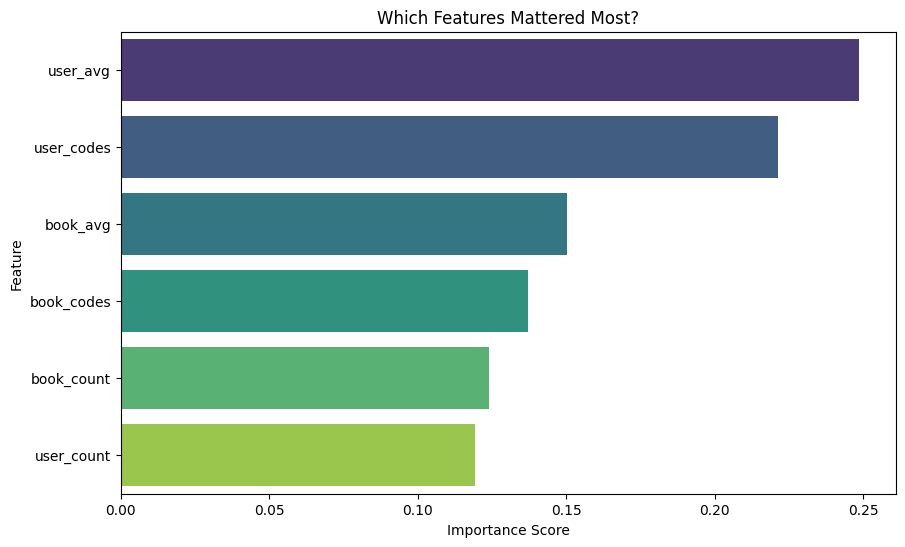

      Feature  Importance
4    user_avg    0.248530
0  user_codes    0.221253
5    book_avg    0.150041
1  book_codes    0.137170
2  book_count    0.123868
3  user_count    0.119138


In [28]:
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Features Mattered Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(feature_importance_df)

In [ ]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)
print(df)
X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [36]:
df = pd.read_csv("train_Interactions.csv")